In [1]:
### Turn one hot encoded .mat to fasta seq
import math
import pandas as pd
import numpy as np
import scipy.io as sio
import scipy
from os.path import dirname, join as pjoin
import os.path
import time
import random
import sys
import gzip

def readInputAsArray(fileName):
    with open(fileName, 'r') as myfile:
        data = myfile.readlines()

    # Strip newline
    for i in range(0, len(data)):
        data[i] = data[i].rstrip()
    # print(data)
    return data

def list_str_to_float(arr):
    out = []
    for i in arr:
        out+=[float(i)]
    return out

def my_print(name, val):
    print(f'{name}: {val}')
    return

def append_list_to_np_arr(lst, np_arr):
    bs_lst=[]
    for i in range(len(lst)):
#         bs_lst+= [[lst[i], lst[i]]]
        bs_lst+= [[lst[i]]]
    
    np_lst=np.array([bs_lst])
#     my_print('np_lst.shape', np_lst.shape)

    if np_arr.shape[0] == 0:
        np_arr = np_lst 
    else:
        np_arr = np.concatenate((np_arr, np_lst), axis=0) 
#     my_print('np_lst.shape', np_arr.shape)
    return np_arr

def append_bplist_to_np_arr(lst, np_arr):
    bp_lst = []
    for i in range(1, len(lst)):
        bp_lst+= [[lst[i-1], lst[i]]]
    np_bp=np.array([bp_lst])
    
#     my_print('np_bp', np_bp.shape)
#     my_print('np_arr', np_arr.shape)
    if np_arr.shape[0] == 0:
        np_arr = np_bp
    else:
        np_arr = np.concatenate((np_arr, np_bp), axis=0) 
#     print(np_arr.shape)
    return np_arr

In [6]:
# Shapes=['Buckle-FL', 'Buckle', 'EP', 'HelT-FL', 'HelT', 'MGW-FL', 'MGW', 
#             'Opening-FL', 'Opening', 'ProT-FL', 'ProT', 'Rise-FL', 'Rise', 'Roll-FL',
#             'Roll', 'Shear-FL', 'Shear', 'Shift-FL', 'Shift', 'Slide-FL', 'Slide', 
#             'Stagger-FL', 'Stagger', 'Stretch-FL', 'Stretch', 'Tilt-FL', 'Tilt']

# bp_Shapes=['Buckle-FL', 'Buckle', 'EP', 'MGW', 'MGW-FL', 'Opening-FL', 'Opening', 
#            'ProT-FL', 'ProT', 'Rise-FL', 'Shear', 'Stagger-FL', 'Stagger', 
#            'Stretch-FL', 'Stretch']

# All_Shapes=[]
# for shape in Shapes:
#     if shape in bp_Shapes:
#         All_Shapes.append(shape + '-F')
#         All_Shapes.append(shape + '-B')
#     else:
#         All_Shapes.append(shape)
        
# # for shape in bs_Shapes:
# #     All_Shapes.append(shape)

# print(len(All_Shapes))
# print(All_Shapes)

In [3]:
import matplotlib as mpl
from matplotlib import pyplot as plt
from matplotlib import cm
import matplotlib.colors
from sklearn.preprocessing import StandardScaler
# from sklearn.preprocessing import MinMaxScaler
# from sklearn.preprocessing import minmax_scale
# from sklearn.preprocessing import MaxAbsScaler
# from sklearn.preprocessing import StandardScaler
# from sklearn.preprocessing import RobustScaler
# from sklearn.preprocessing import Normalizer
# from sklearn.preprocessing import QuantileTransformer
# from sklearn.preprocessing import PowerTransformer
# from sklearn.datasets import fetch_california_housing

In [8]:
## Uses min max scaling to scale all values to unit values
## This scales all the features for one position

def Normalize_data(data):
    scaled_data = []
    max_values  = []
    min_values  = []
    for N in range(data.shape[0]):
        temp = []
        t1   = []
        t2   = []
        for i in range(data.shape[1]):
            max_val = np.max(data[N,i])
            min_val = np.min(data[N,i])
            norm = (data[N,i] - min_val)/(max_val - min_val)
            temp.append(norm)
            t1.append(max_val)
            t2.append(min_val)
        scaled_data.append(temp)
        max_values.append(t1)
        min_values.append(t2)
    return (np.array(scaled_data), np.array(max_values), np.array(min_values))
def InverseNormalize_data(scaled_data, max_values, min_values):
    res_data = []
    for N in range(scaled_data.shape[0]):
        temp = []
        for i in range(scaled_data.shape[1]):
            max_val = max_values[N,i]
            min_val = min_values[N,i]
            #print(max_val)
            #print(min_val)
            orig = (scaled_data[N,i] * (max_val - min_val)) + min_val
            temp.append(orig)
        res_data.append(temp)
    return np.array(res_data)


In [4]:
train_or_test = 'Train'

In [5]:
############################ read input
data_folder = '/home/yibei/Projects/data/train_test_data/'
data_folder='/project/rohs_108/yibeijia/nucleosome_occupancy/data/train_test_data/'
data_folder='/Users/yibeijia/Downloads/nucleosome_occupancy/data/train_test_data/'

total_sections = 5
X_train_og = np.array([]) 
y_train_og = np.array([])
seq_lines=[]
for i in range(total_sections):
    train_fn = 'yeastAll_Shapes_'+train_or_test+'_5seqsPerClustr_'+str(i+1)+'_'+str(total_sections)+'.mat'
    trainmat = scipy.io.loadmat(data_folder+train_fn)
    if X_train_og.shape[0] == 0:
        X_train_og = np.array(trainmat[train_or_test+'_data'])
        y_train_og = np.array(trainmat[train_or_test+'_labels']).T
        seq_lines.append(X_train_og.shape[0])
    else:
        curr_X_train = np.array(trainmat[train_or_test+'_data'])
        curr_y_train = np.array(trainmat[train_or_test+'_labels']).T
        X_train_og = np.concatenate([X_train_og, curr_X_train], axis=0)
        y_train_og = np.concatenate([y_train_og, curr_y_train], axis=0)
        seq_lines.append(curr_X_train.shape[0])
print(X_train_og.shape)
print(y_train_og.shape)
print(seq_lines)



(194305, 146, 42)
(194305, 1)
[38861, 38861, 38861, 38861, 38861]


In [9]:
############################ standard scaling
X_train = X_train_og.copy()
y_full=y_train_og.copy()
print(X_train.shape)
print(X_train.shape[-1])

X_train_expanded=X_train.reshape(-1, X_train.shape[-1])
print(X_train_expanded.shape)

(194305, 146, 42)
42
(28368530, 42)


In [14]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_expanded).reshape(X_train.shape)                        

In [20]:
print(X_train_scaled.shape)
print(X_train_scaled.reshape(-1, X_train_scaled.shape[-1]).shape)

print(X_train.reshape(-1, X_train.shape[-1]).shape)

(194305, 146, 42)
(28368530, 42)
(28368530, 42)


[33, 34, 25, 11, 41]
(28368530,)
(28368530,)
(28368530,)
(28368530,)
(28368530,)
(28368530,)
(28368530,)
(28368530,)
(28368530,)
(28368530,)


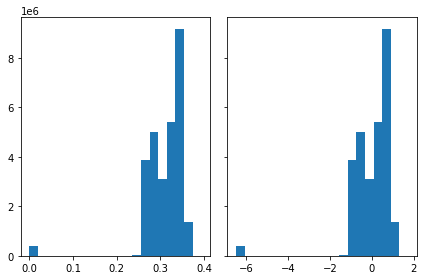

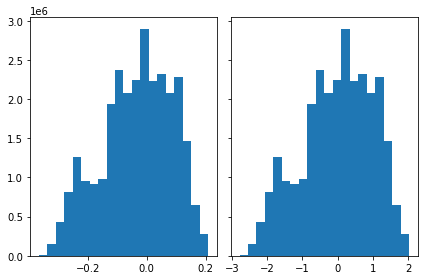

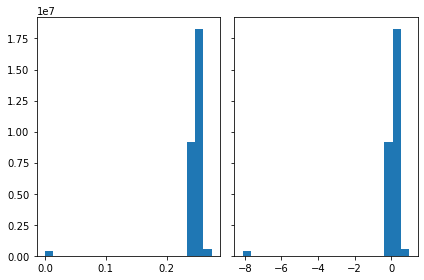

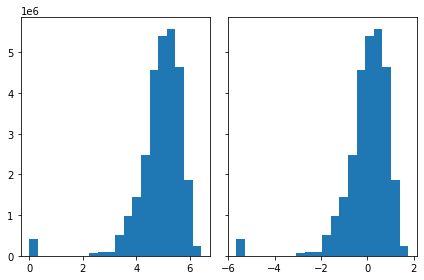

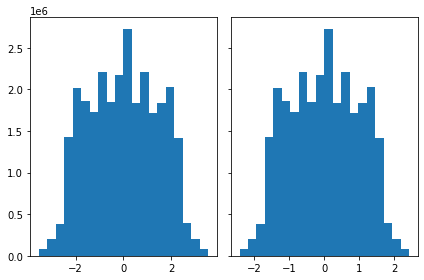

In [25]:
# Make plots to visualize nornamlization

import matplotlib.pyplot as plt
import numpy as np
from matplotlib import colors
n_bins = 20
from random import sample
  
# Prints list of random items of given length
list1 = range(0, 43)
feature_ids = sample(list1,5)
print(feature_ids)

for feature_id in feature_ids:
    fig, axs = plt.subplots(1, 2, sharey=True, tight_layout=True)

    dist_ori = X_train.reshape(-1, X_train.shape[-1])[:,feature_id]
    print(dist_ori.shape)
    dist_scaled = X_train_scaled.reshape(-1, X_train_scaled.shape[-1])[:,feature_id]
    print(dist_scaled.shape)

    axs[0].hist(dist_ori, bins=n_bins)
    axs[1].hist(dist_scaled, bins=n_bins)

In [ ]:
############################ min max scaling
# X_train = X_train_og.copy()
# y_full=y_train_og.copy()

# out = Normalize_data(X_train)
# X_train_normalized = out[0]

# print(X_train_normalized.shape)

## check if min and max are correct
# for N in range(X_train_normalized.shape[0]):
#         for i in range(X_train_normalized.shape[1]):
#                 print('scale after min max')
#                 print(X_train_normalized[N,i].min())
#                 print(X_train_normalized[N,i].max())
#                 print('\noriginal')
#                 print(X_train[N,i].min())
#                 print(X_train[N,i].max())



In [26]:
############################ Write normalized to file

data_folder = '/home/yibei/Projects/data/train_test_data/'
data_folder='/project/rohs_108/yibeijia/nucleosome_occupancy/data/train_test_data/'
data_folder='/Users/yibeijia/Downloads/nucleosome_occupancy/data/train_test_data/'

total_sections = len(seq_lines)
start_lines=0

for i in range(len(seq_lines)):
    end_lines=start_lines+seq_lines[i]

    print('\nwriting: ')
    print(start_lines)
    print(end_lines)

    X_section_to_write = X_train_scaled[start_lines:end_lines, :, :]
    y_section_to_write = y_train_og[start_lines:end_lines]
    print(X_section_to_write.shape)
    print(y_section_to_write.shape)

#     data_path='/project/rohs_108/yibeijia/nucleosome_occupancy/data/train_test_data/'
    data_path='/Users/yibeijia/Downloads/nucleosome_occupancy/data/train_test_data/'

#     Data = {"Test_data" : np.array(Test_data), "Test_labels" : Test_labels}
#     sio.savemat(data_path+species+'ShapeDNNSeqs_Test.mat', Data,  do_compression=True)
    Data = {train_or_test+"_data" : np.array(X_section_to_write), train_or_test+"_labels" : y_section_to_write}
    train_fn = 'yeastAll_Shapes_'+train_or_test+'_5seqsPerClustr_scaled_'+str(i+1)+'_'+str(total_sections)+'.mat'
    sio.savemat(data_path+train_fn, Data,  do_compression=True)

    start_lines = end_lines



writing: 
0
38861
(38861, 146, 42)
(38861, 1)

writing: 
38861
77722
(38861, 146, 42)
(38861, 1)

writing: 
77722
116583
(38861, 146, 42)
(38861, 1)

writing: 
116583
155444
(38861, 146, 42)
(38861, 1)

writing: 
155444
194305
(38861, 146, 42)
(38861, 1)


In [ ]:
# All_Shapes=['Buckle-FL', 'Buckle', 'EP', 'HelT-FL', 'HelT', 'MGW-FL', 'MGW', 
#                 'Opening-FL', 'Opening', 'ProT-FL', 'ProT', 'Rise-FL', 'Rise', 'Roll-FL',
#                 'Roll', 'Shear-FL', 'Shear', 'Shift-FL', 'Shift', 'Slide-FL', 'Slide', 
#                 'Stagger-FL', 'Stagger', 'Stretch-FL', 'Stretch', 'Tilt-FL', 'Tilt']
# # All_Shapes=['Stretch']
# # All_Shapes=['Shift-FL']
# def preprocessShapeFile(seq_file, All_Shapes):
#     out = ''
# #     debug = 0
#     file_list = ['enriched_', 'depleted_']
#     for enriched in file_list:
#         print(enriched)
#         for shape in All_Shapes:

#             print(shape)
#             Seqs = readInputAsArray(seq_file + enriched+shape+'.txt')
#             for line in Seqs:
#     #             if debug > 200: break;
#     #             debug+=1
#                 l = line.split()
#                 if l[1] != '3': # Only consider flanking region of size 3
#                     continue;
#                 curr_seq_shape_list = list_str_to_float(l[2:])
#                 curr_seq = l[0]

#                 if len(curr_seq) > len(curr_seq_shape_list):
#     #                 print(shape)
#     #                 print("base step parameter")
#                     bp_shape = False
#                 else:
#     #                 print("base pair parameter")
#                     bp_shape = True

#                 if bp_shape:
#                     if len(curr_seq_shape_list) < 147:
#                         while len(curr_seq_shape_list) < 147: # if the sequence is shorter than 147
#                             curr_seq_shape_list+=[0]
#                             curr_seq += 'N'
#                         out+=curr_seq + ' ' + l[1] + ' '
#                         out+=' '.join(str(e) for e in curr_seq_shape_list)+'\n'

#                     else:
#                         start = 0
#                          # is a base pair shape, each 147bp seq has 147 shape vals, we use 147-2+1
#                         while (start < len(curr_seq_shape_list)-146):
#                             curr_start = start;
#                             curr_end = 146 + start;
#                             out_seq = curr_seq[curr_start:curr_end+1] 
#                             out_seq_shape_list = curr_seq_shape_list[curr_start: curr_end+1];
#                             start+=1
#                             out+=out_seq + ' ' + l[1] + ' '
#                             out+=' '.join(str(e) for e in out_seq_shape_list)+'\n'
#                 else:
#                     if len(curr_seq_shape_list) < 146:
#                         while len(curr_seq_shape_list) < 146: # if the sequence is shorter than 146
#                             curr_seq_shape_list+=[0]
#                             curr_seq += 'N'
#                         out+=curr_seq + ' ' + l[1] + ' '
#                         out+=' '.join(str(e) for e in curr_seq_shape_list)+'\n'
#                     else:
#     #                     print('>>>>>> Found longer sequences')
#     #                     print(l[0])
#     #                     print((curr_seq_shape_list))
#                         start = 0
#                         # is a base step shape, each 147bp seq has 146 shape vals, we use 146-2+1
#                         while (start < len(curr_seq_shape_list)-146):
#                             curr_start = start;
#                             curr_end = 146 + start;
#                             out_seq = curr_seq[curr_start:curr_end+1] 
#                             start+=1
#                             out+=out_seq + ' ' + l[1] + ' '

#                             out_seq_shape_list = curr_seq_shape_list[curr_start: curr_end];
#                             out+=' '.join(str(e) for e in out_seq_shape_list)+'\n'
# #             f = open(".txt", "w+")
#             with gzip.open(seq_file+'processed_'+enriched+shape+'.gz', 'wb') as f:
#                 f.write(out.encode())
# #             f.write(out)
# #             f.close()

# seq_file='/home/yibei/Downloads/yibei_predictions/'
# preprocessShapeFile(seq_file, All_Shapes)

enriched_
Buckle-FL
Buckle
EP
HelT-FL
HelT
MGW-FL
MGW
Opening-FL
Opening
ProT-FL
ProT
Rise-FL
Rise
Roll-FL
Roll
Shear-FL
Shear
Shift-FL
Shift
Slide-FL
Slide
Stagger-FL
Stagger
Stretch-FL
Stretch
Tilt-FL
Tilt
depleted_
Buckle-FL
Buckle
EP
HelT-FL
HelT
MGW-FL
MGW
Opening-FL
Opening
ProT-FL
ProT
Rise-FL
Rise
Roll-FL
Roll
Shear-FL
Shear
Shift-FL
